In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats
from scipy.stats import t
from matplotlib.patches import Patch

In [ ]:
#calculate TSP
vol_D2O_TSP_uL = 5
total_vol_uL = 600
uL_to_L = 1e-6
D2O_density = 1.11 # 1 g/mL = 1 mg/uL
D2O_TSP_mg = vol_D2O_TSP_uL * D2O_density
TSP_wt_frac = 0.75/100
TSP_Mw = 172.27
TSP_mmol = TSP_wt_frac * D2O_TSP_mg / TSP_Mw
TSP_mM = TSP_mmol / (total_vol_uL * uL_to_L)
print('TSP:', '%.2f' % TSP_mM, 'mM')

TSP: 0.40 mM


: 

In [ ]:
files=['integrals_2', 'integrals_4', 'integrals_10', 'integrals_8', 'integrals_12'] #no TPA
#files = ['cond_A_TPA', 'cond_B_TPA', 'cond_C_TPA', 'cond_D_TPA', 'cond_E_TPA'] #TPA
names=['A', 'B', 'C', 'D', 'E']
conditions = ['2 mM BHET, 0 mM MHET', '2 mM BHET, 2 mM MHET', '2 mM BHET, 0 mM MHET', '2 mM BHET, 10 mM MHET', '0 mM BHET, 10 mM MHET']
time=np.arange(1,12+1,1)*5 
datalist=[]
for i in range(0,len(files)):
    data=np.loadtxt(files[i], delimiter=';', usecols=(1,2,3,4)) #5 if TPA
    assert len(data) == len(time)
    datalist.append(data)

: 

In [ ]:
def change_units(rate, uncertainty, MW):
    c_enzyme=1e-6
    V=600e-6
    n_enzyme=c_enzyme*V
    m_enzyme=MW*n_enzyme
    n_BHET=rate*V*1e-6
    err=uncertainty*V*1e-6
    rate_newunit=n_BHET*1e6/m_enzyme/60 #unit is umol/(g*s)
    uncertainty_newunit=err*1e6/m_enzyme/60 #unit is umol/(g*s)
    return rate_newunit, uncertainty_newunit

: 

In [ ]:
MWs=[22258, 22258, 22258, 22258, 22258] #Molecular weights of the proteins #LCC:27774

: 

slope (95%) [uM/min]: -6.88 +/- 0.52
slope (95%) [umol/(g*s)]: -5.15 +/- 0.39
slope (95%) [uM/min]: -6.36 +/- 0.15
slope (95%) [umol/(g*s)]: -4.76 +/- 0.12
slope (95%) [uM/min]: -8.84 +/- 0.78
slope (95%) [umol/(g*s)]: -6.62 +/- 0.59
slope (95%) [uM/min]: -5.87 +/- 0.51
slope (95%) [umol/(g*s)]: -4.39 +/- 0.38
slope (95%) [uM/min]: -0.07 +/- 0.10
slope (95%) [umol/(g*s)]: -0.06 +/- 0.08


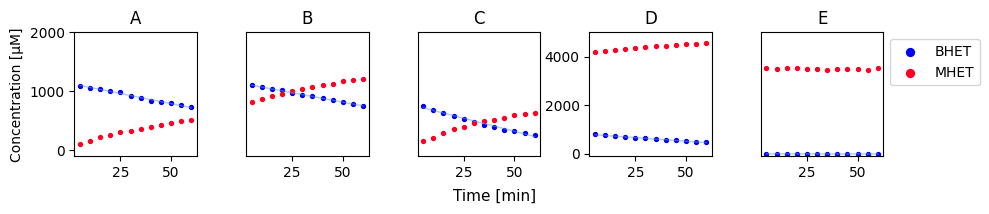

np.float64(nan)

: 

In [ ]:
#plots
fig, axs = plt.subplots(1,5, figsize=(10,2))
slope_bhet=[] #slopes measured in microM/minute
slope_fraction=[] #slopes measured in molar fraction/minute
error_bhet=[]
TSP_list=[]
for i in range(0,len(files)):
    data=datalist[i]
    TSP = (data[:,3]/9) #no TPA
    #TSP = data[:,4]/9 #with TPA
    BHET = 1e3 * TSP_mM * (data[:,0]/4)/TSP
    MHET = 1e3 * TSP_mM * ((data[:,1] + data[:,2])/4)/TSP
    TPA = 1e3 * TSP_mM * (data[:,3]/4)/TSP
    SD = np.std(TSP*1e3)
    
    axs[i].scatter(time,BHET,s=8, color='#0001eeff', label='BHET')
    axs[i].scatter(time,MHET, s=8, color='#ff0022ff', label='MHET')
    
    if i < 3:
        axs[i].set_ylim(-100, 2000)
    else:
        axs[i].set_ylim(-100, 5000)

    #Find rates of BHET degradation
    if i==8: #linear region of LCC-ICCG
        linreg = stats.linregress(time[:4],BHET[:4])
    else: 
        linreg = stats.linregress(time,BHET)
    slope=linreg.slope
    intercept=linreg.intercept
    slope_bhet.append(slope)
    error_bhet.append(linreg.stderr)
    tinv = lambda p, df: abs(t.ppf(p/2, df))
    ts = tinv(0.05, len(time)-2)
    print(f"slope (95%) [uM/min]: {linreg.slope:.2f} +/- {ts*linreg.stderr:.2f}")
    rate_newunit, err_newunit=change_units(linreg.slope, linreg.stderr, MWs[i])
    print(f"slope (95%) [umol/(g*s)]: {rate_newunit:.2f} +/- {ts*err_newunit:.2f}") #unit is umol/(gram enzyme)

    axs[i].plot(time, slope*time+intercept, color='cornflowerblue', alpha=0.5, linewidth=1)


    #Plot fractions
    axs[i].set_title(names[i])
    
for ax in axs[1:3]:   # Subplots 1 and 2
    ax.yaxis.set_visible(False)

for ax in axs[4:]:    # Subplot 4 (last one)
    ax.yaxis.set_visible(False)

axs[4].legend(loc='best', markerscale=2, bbox_to_anchor=(1, 1))
axs[0].set_ylabel('Concentration [µM]')
fig.text(0.5, -0.03, r'Time [min]',  fontsize='11',ha='center')
plt.tight_layout()
fig.subplots_adjust(wspace=0.4)
plt.savefig("Timeresolved_BHET.png", bbox_inches="tight",
            pad_inches=0.3, dpi=300)
plt.show()


TSP_list=np.array(TSP_list)
std_devs = np.std(TSP_list, axis=0)
std_devs

In [ ]:
#TPA slopes

# TPA generation rates without plots

slope_tpa = []

for i in range(len(files)):
    data = datalist[i]

    # Integral 3 = TPA, Integral 4 = TSP
    TPA_integral = data[:,3]
    TSP = data[:,4] / 9

    TPA = 1e3 * TSP_mM * (TPA_integral / 4) / TSP

    linreg = stats.linregress(time, TPA)
    slope_tpa.append(linreg.slope)


# Replicate-based relative error
slopes_0 = [-0.03, -0.01]

error_frac = np.std(slopes_0) / np.mean(slopes_0)
error_tpa = np.abs(error_frac * np.array(slope_tpa))


# Print final TPA generation rates
for name, slope, err in zip(names, slope_tpa, error_tpa):
    print(f"{name}: TPA generation rate = {slope:.2f} +/- {err:.2f} uM/min")

print(error_tpa)
print(slope_tpa)

: 

In [ ]:
# new bhet error slopes

slopes_0 = [6.88, 8.84]
print(np.mean(slopes_0), np.std(slopes_0))
error_frac = np.std(slopes_0)/np.mean(slopes_0)

error_bhet2 = []
error_bhet2.append(error_frac * np.array(slope_bhet))
error_bhet2 = np.abs(error_bhet2)


#print('error_2M', error_frac * 6.36)
#print('error_10M', error_frac * 5.87)
#print('error_0M1', error_frac * 6.88)
#print('error_0M2', error_frac * 8.84)
print(error_bhet2)
print(slope_bhet)

7.859999999999999 0.98
[[0.85746323 0.7934124  1.10158932 0.73165115 0.00926397]]
[6.87720509 6.36349129 8.83519595 5.86814083 0.07430084]


: 

MHET plots:

slope (95%) [uM/min]: 7.27 +/- 0.61
slope (95%) [umol/(g*s)]: 5.44 +/- 0.45
slope (95%) [uM/min]: 7.10 +/- 0.59
slope (95%) [umol/(g*s)]: 5.31 +/- 0.45
slope (95%) [uM/min]: 8.54 +/- 1.16
slope (95%) [umol/(g*s)]: 6.39 +/- 0.87
slope (95%) [uM/min]: 6.44 +/- 0.61
slope (95%) [umol/(g*s)]: 4.83 +/- 0.46
slope (95%) [uM/min]: -0.60 +/- 0.92
slope (95%) [umol/(g*s)]: -0.45 +/- 0.69


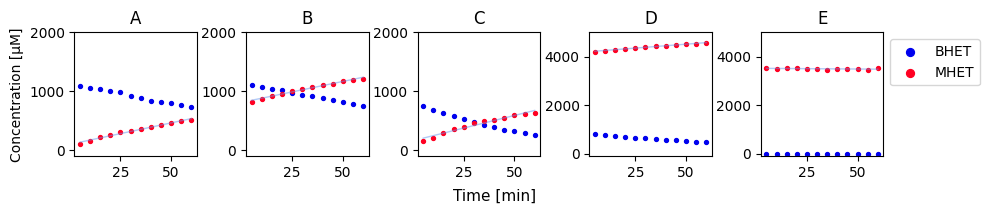

np.float64(nan)

: 

In [ ]:
fig, axs = plt.subplots(1,5, figsize=(10,2))
slope_mhet=[] #slopes measured in microM/minute
slope_fraction=[] #slopes measured in molar fraction/minute
error_mhet=[]
TSP_list=[]
for i in range(0,len(files)):
    data=datalist[i]
    TSP = (data[:,3]/9)
    BHET = 1e3 * TSP_mM * (data[:,0]/4)/TSP
    MHET = 1e3 * TSP_mM * ((data[:,1] + data[:,2])/4)/TSP
    #TPA = 1e3 * TSP_mM * (data[:,4]/4)/TSP
    SD = np.std(TSP*1e3)
    
    axs[i].scatter(time,BHET,s=8, color='#0001eeff', label='BHET')
    axs[i].scatter(time,MHET, s=8, color='#ff0022ff', label='MHET')

    if i < 3:
        axs[i].set_ylim(-100, 2000)
    else:
        axs[i].set_ylim(-100, 5000)

    #Find rates of MHET degradation
    if i==8: #linear region of LCC-ICCG
        linreg = stats.linregress(time[:4],MHET[:4])
    else: 
        linreg = stats.linregress(time,MHET)
    slope=linreg.slope
    intercept=linreg.intercept
    slope_mhet.append(slope)
    error_mhet.append(linreg.stderr)
    tinv = lambda p, df: abs(t.ppf(p/2, df))
    ts = tinv(0.05, len(time)-2)
    print(f"slope (95%) [uM/min]: {linreg.slope:.2f} +/- {ts*linreg.stderr:.2f}")
    rate_newunit, err_newunit=change_units(linreg.slope, linreg.stderr, MWs[i])
    print(f"slope (95%) [umol/(g*s)]: {rate_newunit:.2f} +/- {ts*err_newunit:.2f}") #unit is umol/(gram enzyme)

    axs[i].plot(time, slope*time+intercept, color='cornflowerblue', alpha=0.5, linewidth=1)

    #Plot fractions
    axs[i].set_title(names[i])

axs[4].legend(loc='best', markerscale=2, bbox_to_anchor=(1, 1))
axs[0].set_ylabel('Concentration [µM]')
fig.text(0.5, -0.03, r'Time [min]',  fontsize='11',ha='center')
plt.tight_layout()
fig.subplots_adjust(wspace=0.4)
plt.savefig("Timeresolved_MHET.png", bbox_inches="tight",
            pad_inches=0.3, dpi=300)
plt.show()


TSP_list=np.array(TSP_list)
std_devs = np.std(TSP_list, axis=0)
std_devs

In [ ]:
#new mhet error slopes

slopes_0 = [7.27, 8.54]
print(np.mean(slopes_0), np.std(slopes_0))
error_frac = np.std(slopes_0)/np.mean(slopes_0)

error_mhet2 = []
error_mhet2.append(error_frac * np.array(slope_mhet))
error_mhet2 = np.abs(error_mhet2)

print(error_mhet2)
print(slope_mhet)

7.904999999999999 0.6349999999999998
[[0.58400025 0.57012985 0.68575095 0.51763174 0.04825185]]
[ 7.2701133   7.0974433   8.53678937  6.44390383 -0.60067849]


: 

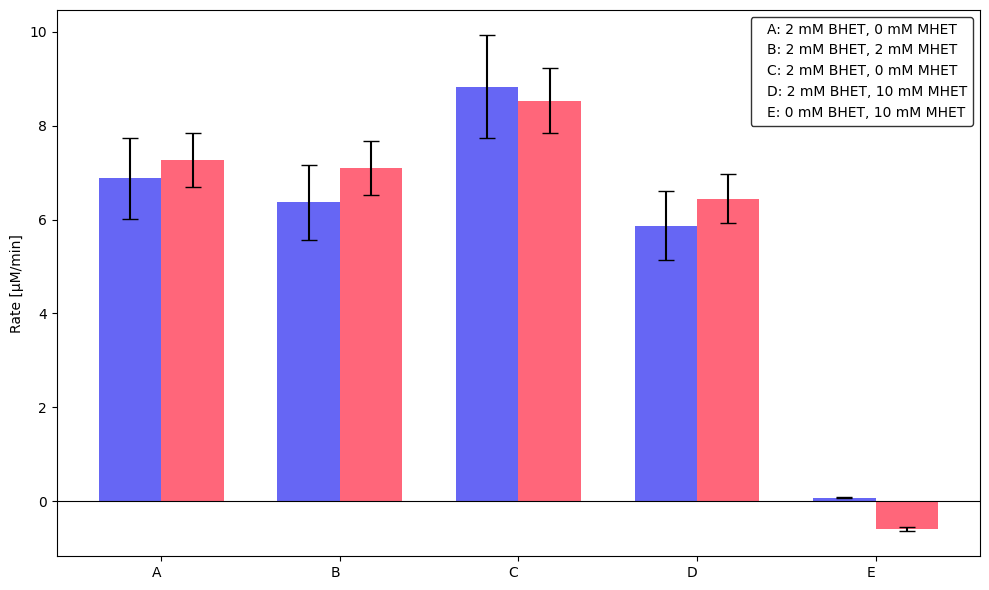

: 

In [ ]:
#Combining the two bar plots into one figure


slope_bhet = np.abs(slope_bhet)
# Convert to 1D numpy arrays
slope_bhet = np.array(slope_bhet).flatten()
slope_mhet = np.array(slope_mhet).flatten()

error_bhet2 = np.array(error_bhet2).flatten()
error_mhet2 = np.array(error_mhet2).flatten()

# Number of conditions
n_conditions = len(names)

# Bar width
bar_width = 0.35

# X positions
x = np.arange(n_conditions)

# Plot
plt.figure(figsize=(10,6))

# BHET (left bars)
plt.bar(x - bar_width/2, slope_bhet,
        yerr=error_bhet2,
        width=bar_width,
        align='center',
        alpha=0.6,
        color='#0001eeff',
        ecolor='black',
        capsize=6,
        label='BHET')

# MHET (right bars)
plt.bar(x + bar_width/2, slope_mhet,
        yerr=error_mhet2,
        width=bar_width,
        align='center',
        alpha=0.6,
        color="#ff0022ff",
        ecolor='black',
        capsize=6,
        label='MHET')

# X-axis labels
plt.xticks(x, names, rotation=0, ha='right')

# Optional: horizontal line at 0 (only needed if you expect negatives)
plt.axhline(0, color='black', linewidth=0.8)

# Labels
plt.ylabel("Rate [µM/min]")


from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color='none', label=f'{names[i]}: {conditions[i]}')
    for i in range(len(names))
]

plt.legend(handles=legend_elements,
           loc='upper right',
           frameon=True,
           facecolor='white',
           edgecolor='black',
           handlelength=0)   # ← removes space



# Layout + save
plt.tight_layout()
plt.savefig("combined_BHET_MHET_grouped.png",
            bbox_inches="tight", pad_inches=0.3, dpi=300)

plt.show()